# Results and model comparison

This notebook does not retrain models. It reads `results/metrics.csv` and the three saved prediction files. Run the model notebooks first if an output is missing.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = PROJECT / "results"
PROCESSED = PROJECT / "data" / "processed"
metrics_path = RESULTS / "metrics.csv"
if not metrics_path.exists():
    raise FileNotFoundError("Run lr.ipynb, SVR.ipynb, and naive_bayes.ipynb first.")
metrics = pd.read_csv(metrics_path)
tte = pd.read_csv(PROCESSED / "tte.csv", parse_dates=["start"])
display(metrics)
print("TTE observations:", len(tte), "satellites:", tte.sat.nunique())


,model,model_key,status,n_observations,n_satellites,cv_folds,rae,rae_percent,mae_days,rmse_days,configuration
0,Linear Regression,lr,success,2437,37,10,4.757590,475.759033,21.890464,39.931592,"{""features"": [""month_sin"", ""month_cos"", ""sun_2..."
1,SVR,svr,success,2437,37,10,1.708568,170.856757,17.578635,41.655598,"{""features"": [""month_sin"", ""month_cos"", ""sun_2..."
2,Naive Bayes Survival,naive_bayes,success,2437,37,10,30.151401,3015.140054,91.732949,107.400761,"{""features"": [""month_sin"", ""month_cos"", ""sun_2..."


TTE observations: 2437 satellites: 37


,TTE days
count,2437.000000
mean,21.474354
std,41.687573
min,1.000000
25%,2.000000
50%,7.000000
75%,20.000000
max,358.000000


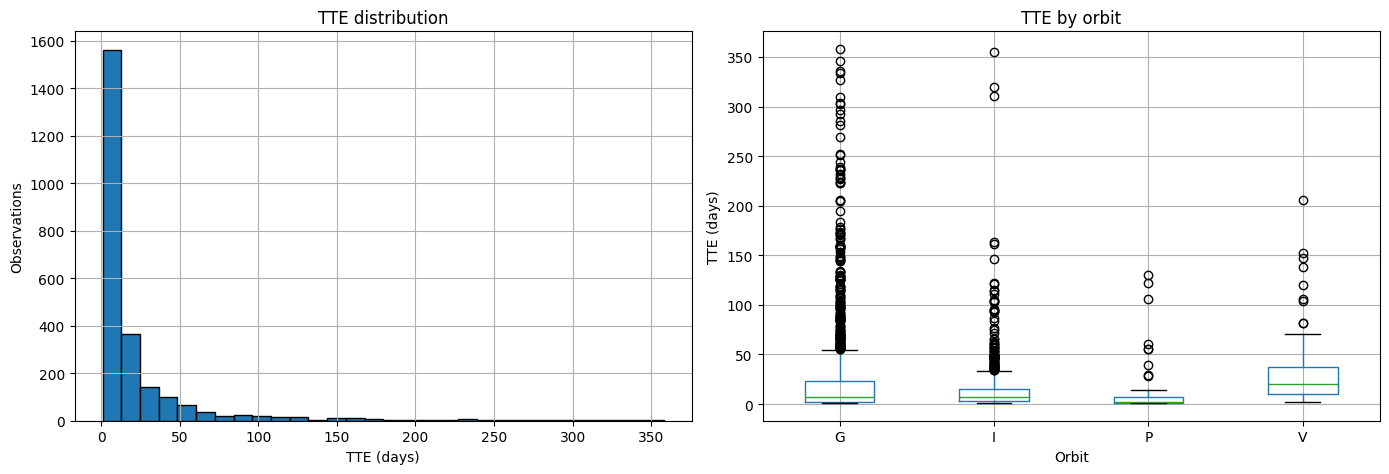

In [2]:
display(tte.tte.describe(percentiles=[.25, .5, .75]).to_frame("TTE days"))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tte.tte.hist(bins=30, edgecolor="black", ax=axes[0]); axes[0].set(title="TTE distribution", xlabel="TTE (days)", ylabel="Observations")
tte.boxplot(column="tte", by="orbit", ax=axes[1]); axes[1].set(title="TTE by orbit", xlabel="Orbit", ylabel="TTE (days)")
plt.suptitle(""); plt.tight_layout(); plt.show()


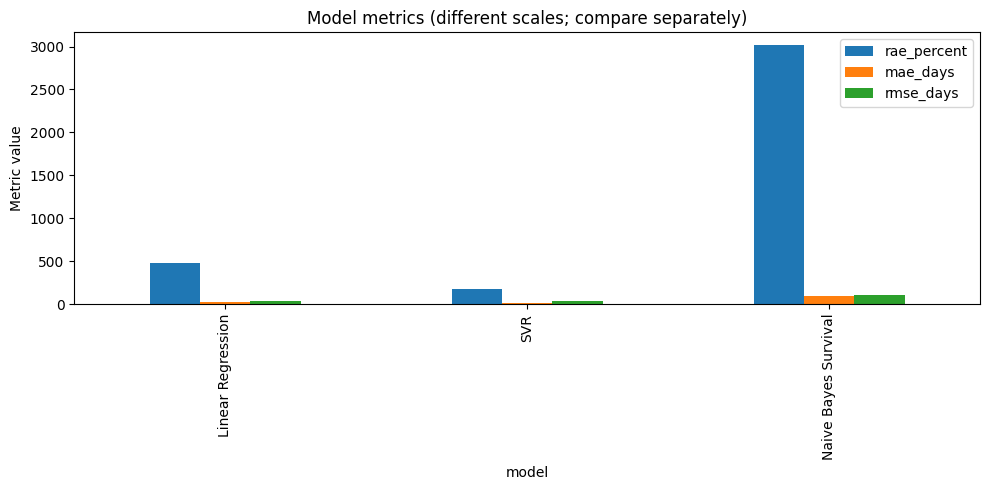

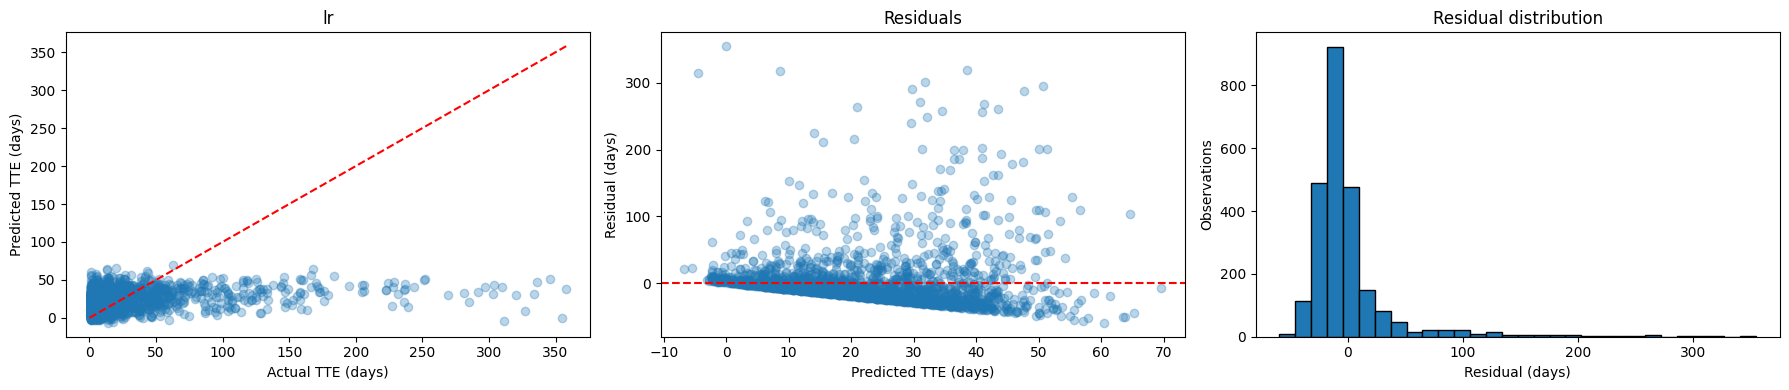

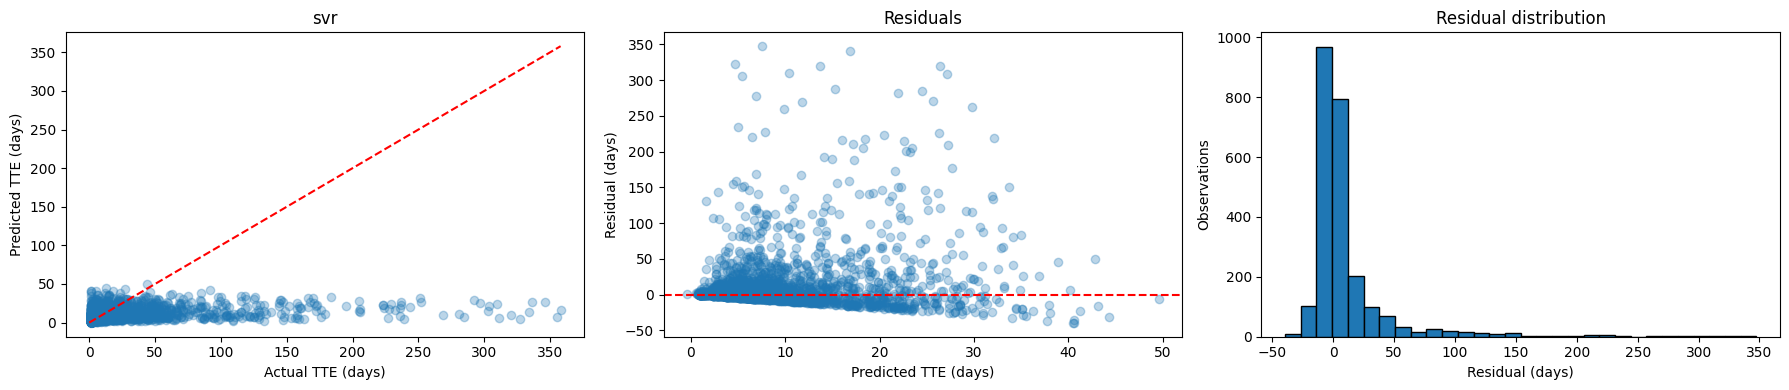

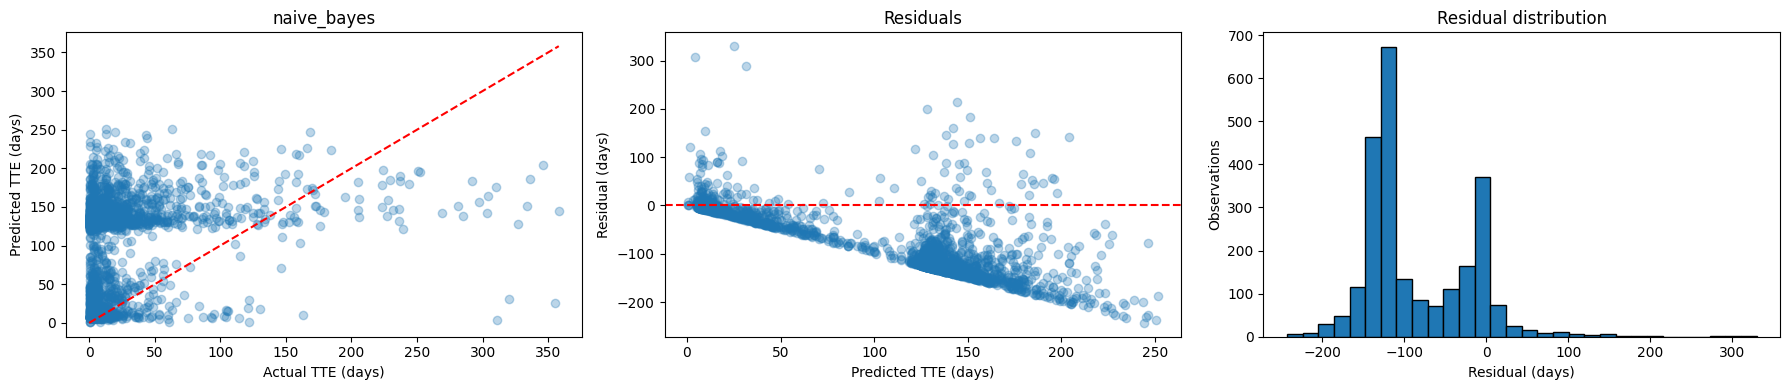

In [3]:
successful = metrics[metrics.status.eq("success")]
if successful.empty:
    raise ValueError("No successful model metrics are available.")
successful.set_index("model")[["rae_percent", "mae_days", "rmse_days"]].plot.bar(figsize=(10, 5), title="Model metrics (different scales; compare separately)")
plt.ylabel("Metric value"); plt.tight_layout(); plt.show()
for key in ["lr", "svr", "naive_bayes"]:
    path = RESULTS / f"predictions_{key}.csv"
    if not path.exists():
        print(f"Missing {path.name}: run {key if key != 'lr' else 'lr'}.ipynb first")
        continue
    prediction = pd.read_csv(path)
    prediction["residual"] = prediction.actual_tte - prediction.predicted_tte
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    limit = max(prediction.actual_tte.max(), prediction.predicted_tte.max())
    axes[0].scatter(prediction.actual_tte, prediction.predicted_tte, alpha=.3); axes[0].plot([0, limit], [0, limit], "r--"); axes[0].set(title=key, xlabel="Actual TTE (days)", ylabel="Predicted TTE (days)")
    axes[1].scatter(prediction.predicted_tte, prediction.residual, alpha=.3); axes[1].axhline(0, color="r", linestyle="--"); axes[1].set(title="Residuals", xlabel="Predicted TTE (days)", ylabel="Residual (days)")
    axes[2].hist(prediction.residual, bins=30, edgecolor="black"); axes[2].set(title="Residual distribution", xlabel="Residual (days)", ylabel="Observations")
    plt.tight_layout(); plt.show()


## Interpretation

The original Stanford test-set RAE benchmarks were Linear Regression 475%, SVR 190%, and Modified Naive Bayes 167%. These are original-study benchmarks, not results from this implementation. The local comparison uses pooled shuffled KFold predictions; observations from the same satellite can appear in both training and validation folds. The custom Naive Bayes Survival method is an approximation of the published approach. Positive residuals mean underprediction because residuals are defined as actual minus predicted.